# NLP & Sentiment Analysis

## Objetivo

Extraer insights sobre la percepción de los productos a partir del 
texto libre de las reseñas. El análisis combina sentiment scoring 
automático con el rating numérico del reviewer para identificar 
discrepancias que revelan patrones no capturables con métricas 
cuantitativas solas.

## Enfoque

Se utiliza VADER (Valence Aware Dictionary and sEntiment Reasoner), 
optimizado para texto de consumidores en inglés. El rating `overall` 
actúa como ground truth para validar y contrastar los scores de sentiment.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ast
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

AMAZON_PATH = os.path.join('..', 'data', 'Musical_instruments_reviews.csv')
OUTPUTS_DIR = os.path.join('..', 'outputs')

df = pd.read_csv(AMAZON_PATH)
df = df.dropna(subset=['reviewText']).copy()
df['overall'] = df['overall'].astype(int)
df['reviewTime'] = pd.to_datetime(df['reviewTime'])
df['helpful_votes'] = df['helpful'].apply(lambda x: ast.literal_eval(x)[0])
df['total_votes']   = df['helpful'].apply(lambda x: ast.literal_eval(x)[1])

print(f"Shape: {df.shape}")
df.head(3)

Shape: (10254, 11)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,helpful_votes,total_votes
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5,good,1393545600,2014-02-28,0,0
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5,Jake,1363392000,2013-03-16,13,14
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5,It Does The Job Well,1377648000,2013-08-28,1,1


---
## 1. Sentiment Scoring con VADER

VADER asigna a cada texto un score compuesto (`compound`) entre -1 
(máximo negativo) y +1 (máximo positivo). A partir de ese score 
se define una etiqueta de sentiment con los umbrales estándar 
de la librería:

- `compound >= 0.05` → positivo  
- `compound <= -0.05` → negativo  
- entre ambos → neutral

In [2]:
analyzer = SentimentIntensityAnalyzer()

df['compound'] = df['reviewText'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

df['sentiment'] = df['compound'].apply(
    lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
)

print("Distribución de sentiment:")
print(df['sentiment'].value_counts())
print(f"\nCompound score — estadísticas:")
print(df['compound'].describe().round(3))

Distribución de sentiment:
sentiment
positive    9172
negative     803
neutral      279
Name: count, dtype: int64

Compound score — estadísticas:
count    10254.000
mean         0.662
std          0.410
min         -0.978
25%          0.572
50%          0.830
75%          0.935
max          1.000
Name: compound, dtype: float64


### Relación entre sentiment score y rating numérico

El sesgo positivo del dataset (89.4% de reseñas clasificadas como 
positivas) es consistente con la distribución de ratings observada 
en el EDA. El valor analítico está en las discrepancias: reseñas 
donde el sentiment de VADER y el rating del usuario no coinciden.

In [3]:
sentiment_by_rating = (
    df.groupby('overall')
    .agg(
        avg_compound  = ('compound', 'mean'),
        count         = ('compound', 'count'),
        pct_positive  = ('sentiment', lambda x: (x == 'positive').mean() * 100),
        pct_negative  = ('sentiment', lambda x: (x == 'negative').mean() * 100)
    )
    .round(2)
)

print("Sentiment por nivel de rating:")
print(sentiment_by_rating)

discrepancies = df[
    ((df['overall'] <= 2) & (df['sentiment'] == 'positive')) |
    ((df['overall'] >= 4) & (df['sentiment'] == 'negative'))
].copy()

print(f"\nDiscrepancias totales: {len(discrepancies)}")
print(f"  Rating bajo (≤2) con sentiment positivo: {((df['overall'] <= 2) & (df['sentiment'] == 'positive')).sum()}")
print(f"  Rating alto (≥4) con sentiment negativo: {((df['overall'] >= 4) & (df['sentiment'] == 'negative')).sum()}")

Sentiment por nivel de rating:
         avg_compound  count  pct_positive  pct_negative
overall                                                 
1                0.04    217         46.54         46.54
2                0.20    250         59.20         36.40
3                0.47    772         77.46         17.49
4                0.64   2083         88.53          8.40
5                0.73   6932         93.49          4.34

Discrepancias totales: 725
  Rating bajo (≤2) con sentiment positivo: 249
  Rating alto (≥4) con sentiment negativo: 476


### Visualización: compound score por rating

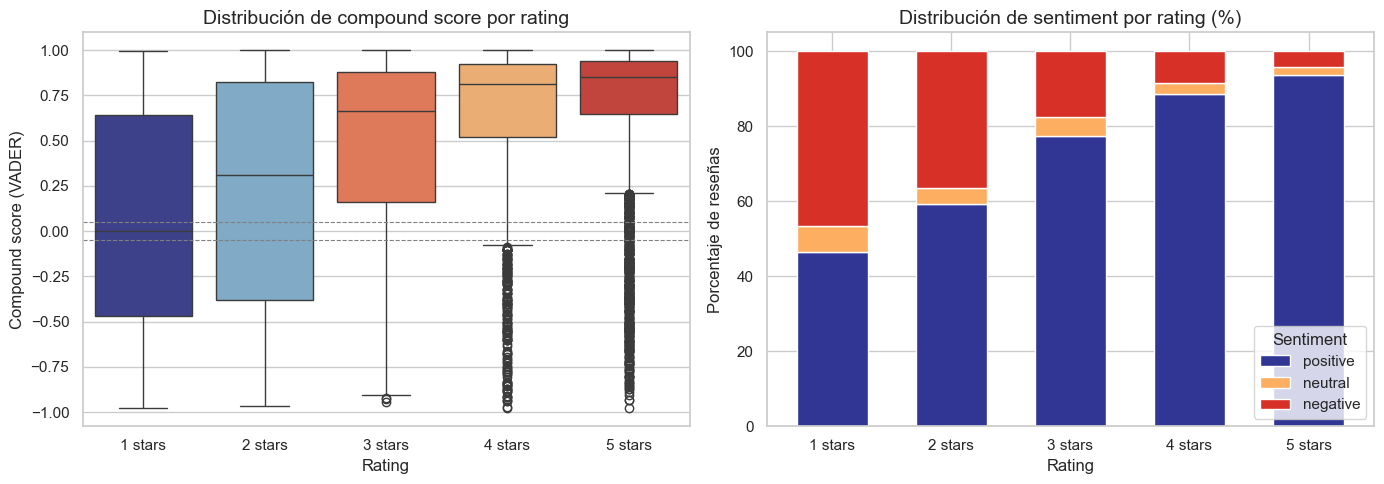

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['overall_str'] = df['overall'].astype(str) + ' stars'
order = ['1 stars', '2 stars', '3 stars', '4 stars', '5 stars']
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#313695']

sns.boxplot(data=df, x='overall_str', y='compound', order=order,
            hue='overall_str', palette=colors, legend=False, ax=axes[0])
axes[0].set_title('Distribución de compound score por rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Compound score (VADER)')
axes[0].axhline(y=0.05, color='gray', linestyle='--', linewidth=0.8)
axes[0].axhline(y=-0.05, color='gray', linestyle='--', linewidth=0.8)

sentiment_pct = df.groupby(['overall', 'sentiment']).size().unstack(fill_value=0)
sentiment_pct = sentiment_pct.div(sentiment_pct.sum(axis=1), axis=0) * 100

sentiment_pct[['positive', 'neutral', 'negative']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#313695', '#fdae61', '#d73027'],
    width=0.6
)
axes[1].set_title('Distribución de sentiment por rating (%)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Porcentaje de reseñas')
axes[1].set_xticklabels([f'{i} stars' for i in range(1, 6)], rotation=0)
axes[1].legend(title='Sentiment', loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'sentiment_by_rating.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Análisis de Discrepancias

Las discrepancias entre rating y sentiment revelan patrones que 
ninguna de las dos métricas captura por separado. Se analizan 
dos casos:

- **Rating bajo con sentiment positivo**: el reviewer expresa 
  satisfacción en el texto pero penaliza con un rating bajo. 
  Posibles causas: expectativas no cumplidas, problemas de entrega, 
  o disconformidad con el precio.
- **Rating alto con sentiment negativo**: el reviewer puntúa alto 
  pero el texto contiene lenguaje negativo. Posible causa: sarcasmo, 
  comparaciones negativas con otros productos, o menciones de 
  problemas menores que no afectaron la experiencia general.

In [6]:
low_rating_pos = df[(df['overall'] <= 2) & (df['sentiment'] == 'positive')].copy()
high_rating_neg = df[(df['overall'] >= 4) & (df['sentiment'] == 'negative')].copy()

print("=== Rating bajo (≤2) con sentiment POSITIVO ===\n")
for _, row in low_rating_pos.nlargest(3, 'compound').iterrows():
    print(f"Rating: {row['overall']} | Compound: {row['compound']:.3f}")
    print(f"Texto: {row['reviewText'][:300]}")
    print()

print("=== Rating alto (≥4) con sentiment NEGATIVO ===\n")
for _, row in high_rating_neg.nsmallest(3, 'compound').iterrows():
    print(f"Rating: {row['overall']} | Compound: {row['compound']:.3f}")
    print(f"Texto: {row['reviewText'][:300]}")
    print()

=== Rating bajo (≤2) con sentiment POSITIVO ===

Rating: 2 | Compound: 1.000
Texto: From Greg Abrams review, entitled "For all but the tone snobs," a review further down on this product's page:"Alright, so you want to get a good (if somewhat "basic") distortion sound for less than $100? This is your deal."I strongly disagree.  You can find MUCH BETTER distortions for $100 or less, 

Rating: 1 | Compound: 0.998
Texto: My review(s) for this have changed a few times, but no more. When I first got it I liked the sound, though it did sound a little cold and digital, and this is from someone wanting to record shoegaze/dreampop, which by it's nature is full of cold tones (reverb/chorus/delay) shimmering, a la cocteau t

Rating: 2 | Compound: 0.997
Texto: I've owned more than one overdrive pedal in my 30 years of playing guitar and the only one I still have on my pedal board is the Boss Super Overdrive...Sweet Baby is well on the way of living up to that legend as well. I have nothing but high

### Wordcloud por segmento de rating

Se comparan los términos más frecuentes en reseñas de 1 y 2 estrellas 
versus reseñas de 4 y 5 estrellas para identificar vocabulario 
diferenciador entre experiencias negativas y positivas.

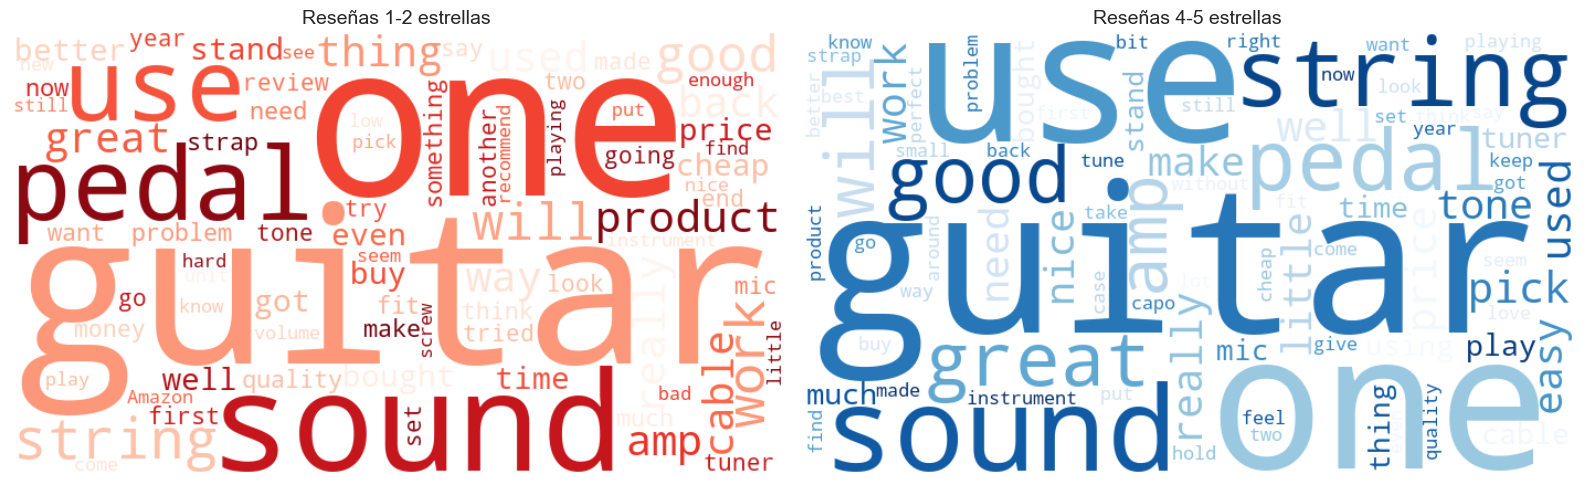

In [7]:
from wordcloud import WordCloud

text_negative = ' '.join(df[df['overall'] <= 2]['reviewText'].tolist())
text_positive = ' '.join(df[df['overall'] >= 4]['reviewText'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, title, color in zip(
    axes,
    [text_negative, text_positive],
    ['Reseñas 1-2 estrellas', 'Reseñas 4-5 estrellas'],
    ['Reds', 'Blues']
):
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=color,
        max_words=80,
        stopwords=None
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'wordcloud_by_rating.png'), dpi=150, bbox_inches='tight')
plt.show()

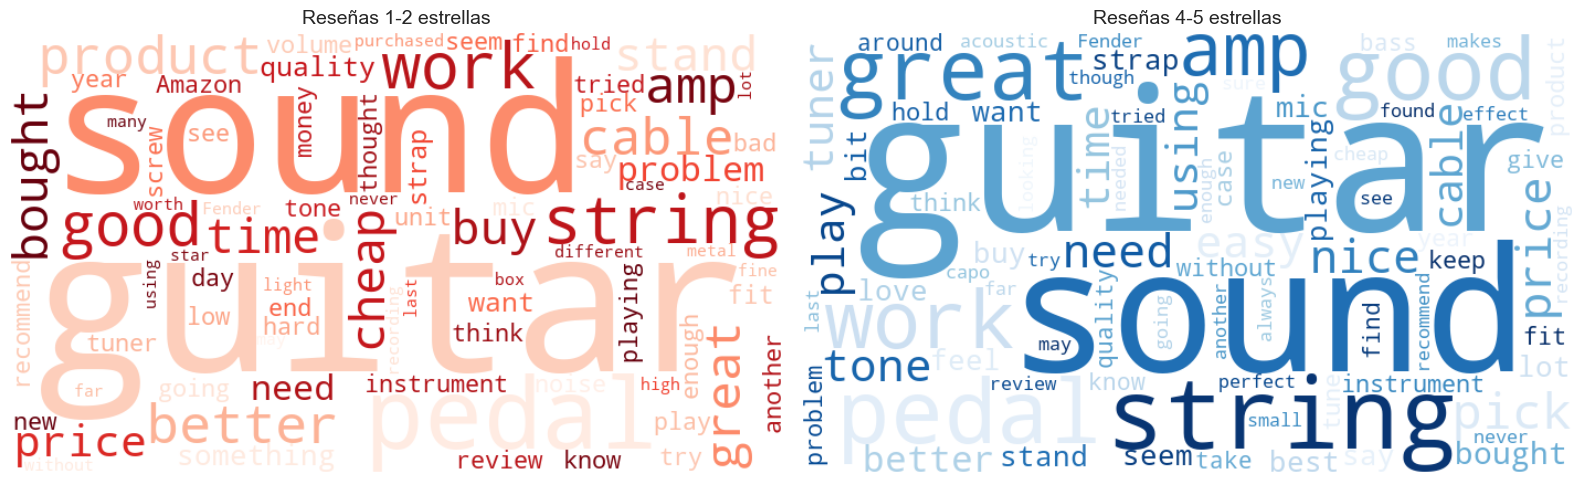

In [8]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = STOPWORDS.union({
    'one', 'use', 'get', 'got', 'will', 'thing', 'also', 
    'much', 'really', 'even', 'still', 'way', 'used',
    'make', 'made', 'come', 'go', 'now', 'two', 'little',
    'well', 'back', 'right', 'first', 'set', 'put', 'look'
})

text_negative = ' '.join(df[df['overall'] <= 2]['reviewText'].tolist())
text_positive = ' '.join(df[df['overall'] >= 4]['reviewText'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, title, color in zip(
    axes,
    [text_negative, text_positive],
    ['Reseñas 1-2 estrellas', 'Reseñas 4-5 estrellas'],
    ['Reds', 'Blues']
):
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=color,
        max_words=80,
        stopwords=custom_stopwords
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'wordcloud_by_rating.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones

**Sentiment general:** el 89.4% de las reseñas tiene sentiment positivo, 
consistente con la distribución de ratings (87.9% ≥ 4 estrellas). 
VADER es efectivo como primer nivel de análisis pero tiene limitaciones 
documentadas con citas textuales y nombres de productos con carga 
semántica negativa (e.g. "Hell Babe wah pedal").

**Discrepancias (725 reseñas):**
- 249 reseñas con rating bajo y sentiment positivo: frecuentemente 
  asociadas a expectativas de precio o comparaciones con otros productos.
- 476 reseñas con rating alto y sentiment negativo: en muchos casos 
  causadas por lenguaje de advertencia o nombres de productos que VADER 
  interpreta negativamente.

**Vocabulario diferenciador:**
- Reseñas negativas: "cheap", "problem", "better", señalan insatisfacción 
  con calidad percibida vs. precio pagado.
- Reseñas positivas: "great", "easy", "perfect", "love", vocabulario 
  de satisfacción sin ambigüedad.